<a href="https://colab.research.google.com/github/Yalda-Ashrafi/Arch-Technologies-ML-Internship-Month2/blob/main/Yalda_Ashrafi_MachineLearning_Month2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Internship Domain: Machine Learning
### Arch Technologies - Month 2 Project
### Submitted By:
### Full Name: Yalda Ashrafi
### Email Address: yaldaashrafi54@gmail.com
### Phone Number: +601113304425

### Date: June 15, 2026
### Organization: Arch Technologies

### Introduction
This project focuses on building a machine learning model to predict housing prices using the California housing dataset. By leveraging supervised learning techniques, the model analyzes key features such as location, number of rooms, and population to automate price estimation. The project encompasses the entire machine learning lifecycle: data cleaning, feature engineering, model training, and performance evaluation.[link text](https://)

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv("housing.csv")

# View the column names

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_INLAND      20640 non-null  bool   
 10  ocean_proximity_ISLAND      20640 non-null  bool   
 11  ocean_proximity_NEAR BAY    20640 non-null  bool   
 12  ocean_proximity_NEAR OCEAN  20640 non-null  bool   
 13  rooms_per_household         206

# View the first 5 rows

In [14]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,pop_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False,6.984127,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False,6.238137,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False,8.288136,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False,5.817352,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False,6.281853,2.181467


#  Data Cleaning

In [4]:

imputer = SimpleImputer(strategy="median")
df['total_bedrooms'] = imputer.fit_transform(df[['total_bedrooms']])
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

#  Feature Engineering

In [5]:

df['rooms_per_household'] = df['total_rooms'] / df['households']
df['pop_per_household'] = df['population'] / df['households']

# Model Training

In [18]:

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

#  Evaluation

In [11]:

y_pred = model.predict(X_test_scaled)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")

R2 Score: 0.8108
RMSE: 49,793.89


### Residual Plot

A residual plot helps to visualize the errors of a prediction model. It displays the residuals (the difference between observed and predicted values) on the y-axis and the independent variable (or predicted values) on the x-axis. A good model will have residuals randomly scattered around the horizontal line at zero, with no discernible pattern. If a pattern is observed, it indicates that the model might not be capturing some underlying structure in the data.

## Model Diagnostic: Residual Plot Analysis

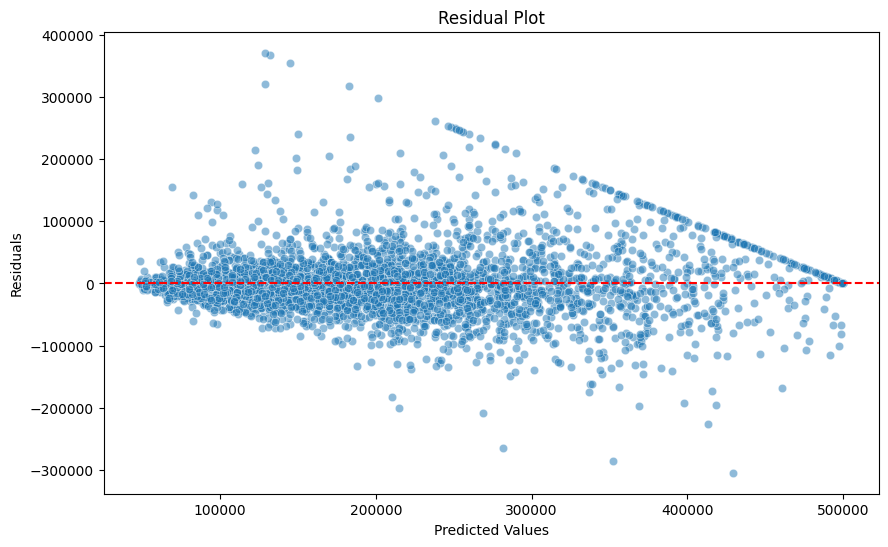

In [19]:

y_pred = model.predict(X_test_scaled)
residuals = y_test - y_pred


plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.savefig("residual_plot.png")
plt.show()

#  Feature Importance Bar Chart

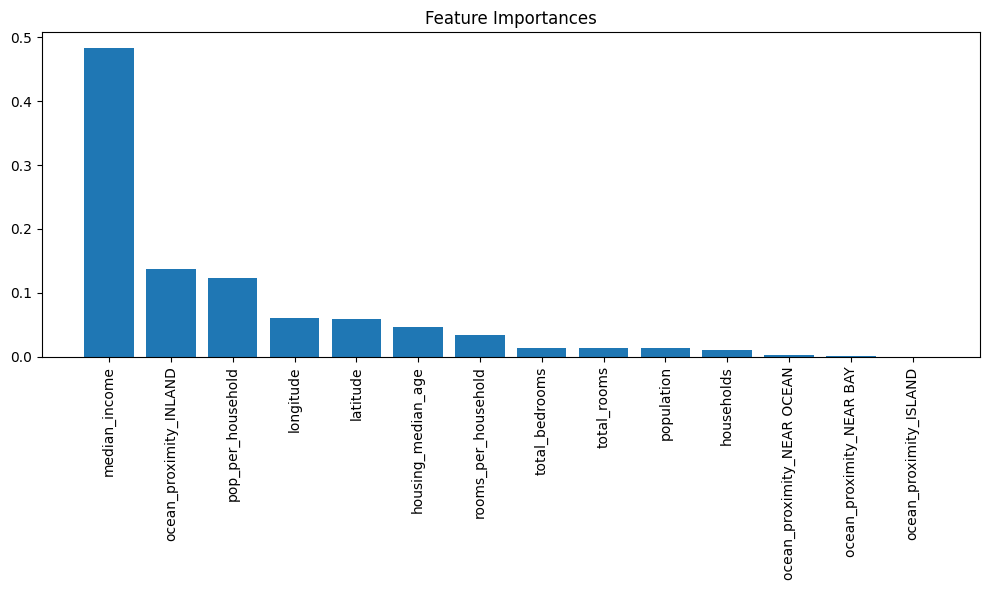

In [20]:

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.savefig("feature_importance.png") # Saves to your Colab files
plt.show()

## Project Methodology Summary

## 1.Data Preprocessing & CleaningMissing
 Data: The total_bedrooms column contained missing values, which were addressed using a Median Imputer.  Categorical Encoding: The ocean_proximity feature was transformed using One-Hot Encoding to convert categorical geographic data into a numerical format suitable for machine learning algorithms.

## 2. Feature Engineering
#### To enhance model performance, new features were created, including rooms_per_household and pop_per_household, providing the model with more descriptive insights into housing density and demographics.

##  3. Model TrainingAlgorithm:
A Random Forest Regressor was selected for its robustness in handling non-linear relationships.  Scaling: Features were processed using StandardScaler to ensure consistency in data ranges, allowing for more accurate model convergence.

##  4. Model EvaluationMetrics:
The model's accuracy was assessed using the R² Score (measuring explained variance) and the RMSE (measuring prediction error in dollars).  Diagnostics: Visualizations, including a Correlation Heatmap, Feature Importance Bar Chart, and Residual Plot, were generated to interpret the model's logic and validate prediction reliability

## R² Score (0.8108):
 This is the coefficient of determination. It tells us that our model successfully captures 81.08% of the variability in housing prices based on the provided features. In machine learning, a score closer to 1.0 indicates a high-performing model that explains the data well.

## RMSE (49,793.89):
This is the Root Mean Squared Error. It represents the average prediction error in dollars. It signifies that, on average, our model's predicted house price is off by approximately 49,794 compared to the actual market value.